# 00. Style Guide & Visual Standards

This notebook defines and tests the visual standards for the Nørrebro exploratory analysis.
It uses the custom `src.visualization.style` module to ensure consistency across all subsequent notebooks.

**Goals:**
1. Verify `src.visualization.style` is importable and working.
2. Visualize the defined color palettes.
3. Test standard plot types (Bar, Line, Scatter, Simple Map).
4. **NEW**: Test Basemap integration (Contextily).

In [1]:
import sys
from pathlib import Path

# Add project root to sys.path to access src modules
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, box
import contextily as ctx

# Import custom style
from src.visualization import style

# Apply the style
style.apply_style()

## 1. Color Palette Visualization

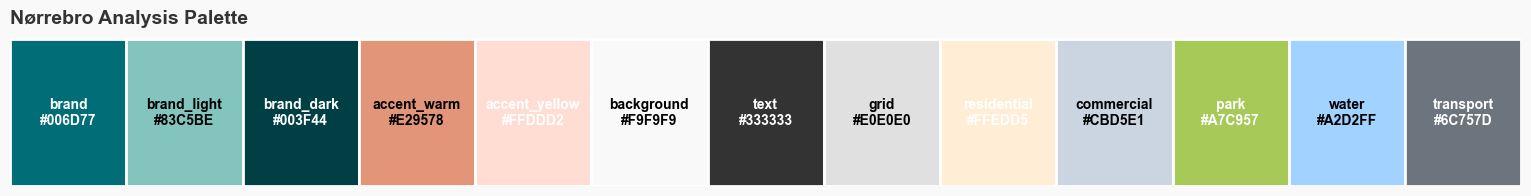

In [ ]:
def plot_palette(palette_dict, title):
    colors = list(palette_dict.values())
    names = list(palette_dict.keys())
    n = len(colors)

    fig, ax = plt.subplots(figsize=(n * 1.5, 2))
    ax.bar(range(n), [1] * n, color=colors, width=1, edgecolor="white", linewidth=2)

    for i, (name, color) in enumerate(zip(names, colors)):
        ax.text(
            i,
            0.5,
            f"{name}\n{color}",
            ha="center",
            va="center",
            color="white" if i % 2 == 0 else "black",
            fontweight="bold",
        )

    ax.set_xlim(-0.5, n - 0.5)
    ax.axis("off")
    ax.set_title(title, loc="left")
    plt.show()


# Plot the main palette
plot_palette(style.PALETTE, "Nørrebro Analysis Palette")

## 2. Standard Plot Types

In [ ]:
# Generate dummy data
np.random.seed(42)
df = pd.DataFrame(
    {
        "Category": ["A", "B", "C", "D", "E"],
        "Value": np.random.randint(10, 100, 5),
        "Group": ["G1", "G1", "G2", "G2", "G3"],
    }
)

ts_data = pd.DataFrame(
    {
        "Time": pd.date_range("2023-01-01", periods=20),
        "Metric": np.cumsum(np.random.randn(20)),
        "Metric2": np.cumsum(np.random.randn(20)),
    }
)

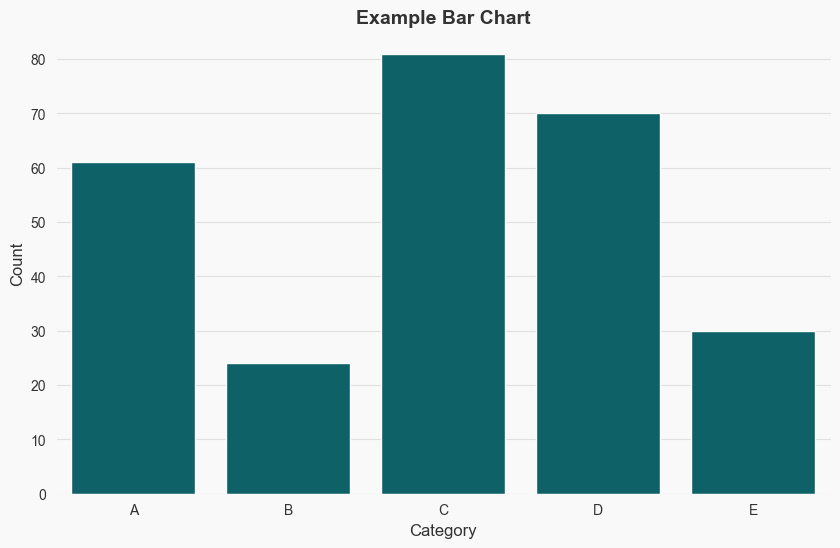

In [ ]:
# Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Category", y="Value", color=style.PALETTE["brand"])
plt.title("Example Bar Chart")
plt.xlabel("Category")
plt.ylabel("Count")
sns.despine()
plt.show()

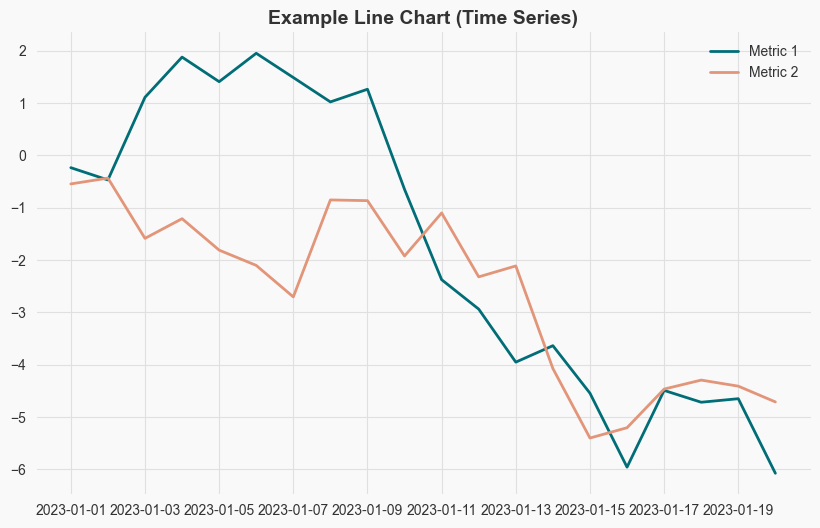

In [ ]:
# Line Chart with Multiple Series
plt.figure(figsize=(10, 6))
plt.plot(ts_data["Time"], ts_data["Metric"], label="Metric 1")
plt.plot(ts_data["Time"], ts_data["Metric2"], label="Metric 2")
plt.title("Example Line Chart (Time Series)")
plt.legend()
sns.despine()
plt.show()

## 3. Dummy Map Visualization (Simple)
Testing basic GeoPandas plotting with the style.

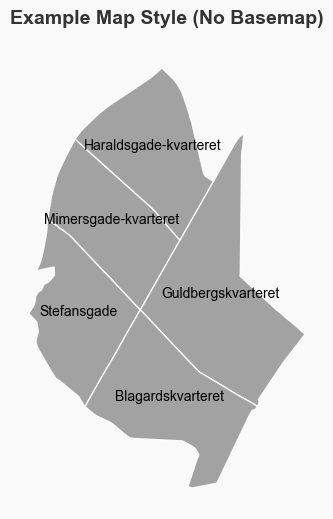

In [ ]:
# Create dummy geometry (EPSG:25832 - Denmark)
# Center roughly on Nørrebro (UTM32N: ~723000, 6178000)
norrebro_center = Point(723500, 6178500)

gdf = gpd.read_file("../data/processed/norrebro_boundary.gpkg", layer="neighbourhoods")

fig, ax = plt.subplots(figsize=(10, 6))

# Apply categorical colors
colors = [style.get_categorical_color(t) for t in gdf["neighbourhood_name"]]

gdf.plot(ax=ax, color=colors, edgecolor="white", alpha=0.9)

# Annotate
for idx, row in gdf.iterrows():
    ax.text(
        row.geometry.centroid.x,
        row.geometry.centroid.y,
        row["neighbourhood_name"],
        ha="center",
        color="black" if row["neighbourhood_name"] != "Transport" else "white",
    )

ax.set_title("Example Map Style (No Basemap)")
ax.set_axis_off()

# Keep aspect ratio equal
ax.set_aspect("equal")

plt.show()

## 4. Map with Basemap (CartoDB Positron)
Verifying `contextily` integration via `style.add_basemap`.

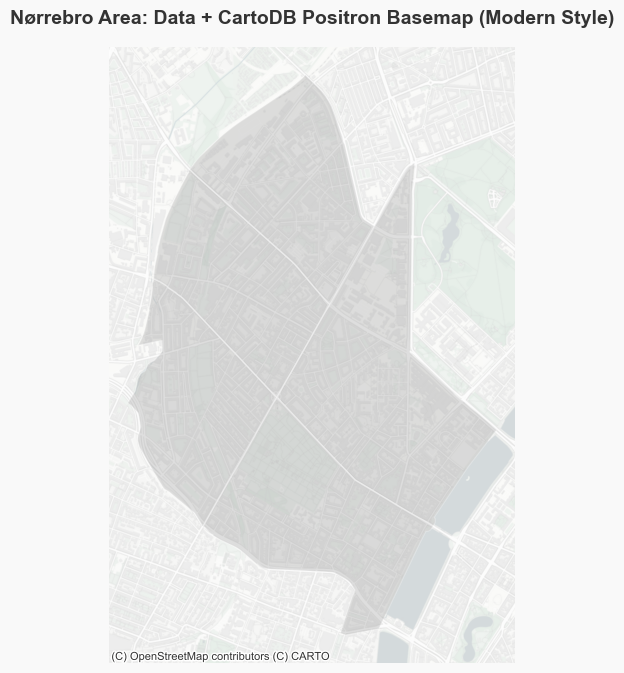

In [ ]:
# Load actual boundary to get real Nørrebro location if possible, or use the dummy gdf above
# Using the dummy gdf which is positioned in Nørrebro coordinates (EPSG:25832)

fig, ax = plt.subplots(figsize=(12, 8))

# Plot data first
gdf.plot(ax=ax, color=colors, edgecolor="white", alpha=0.3, linewidth=1)

# Add Basemap via styler
# Note: ensuring CRS matches the data (EPSG:25832)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832")

ax.set_title("Nørrebro Area: Data + CartoDB Positron Basemap (Modern Style)")
ax.set_axis_off()
plt.show()